# Mini Project 4

In this final mini project, I explore the impact of a non-constant $\sigma$ on the distribution of profits of hedging. 

In [1]:
#Package Import
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import shapiro
import scipy.stats as stats
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import quad
sns.set_style('darkgrid')
from scipy.optimize import minimize
from joblib import Parallel, delayed
from scipy.stats import rv_discrete
from statsmodels.stats.diagnostic import acorr_ljungbox


%run functions.py

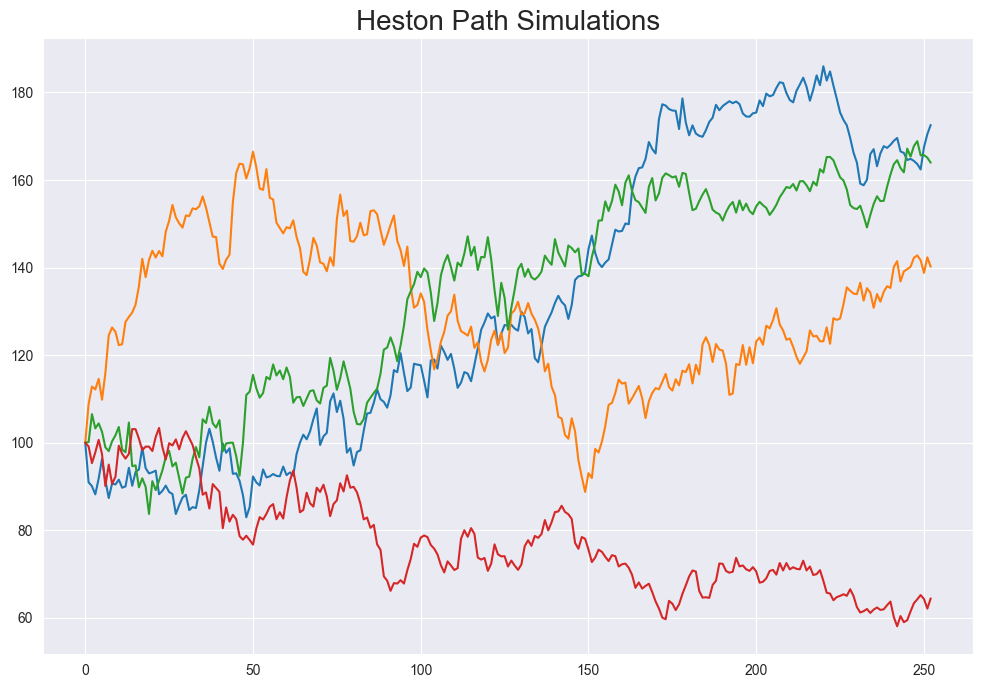

In [ ]:
#Generation of custom stock paths following Geometeric Brownian motion, but log-returns do not have constant volatility.
 #Custom sigma that is not constant
#paramters: 
S0 = 100
v0 = .22*2
t = 1
r = 0.035 #risk-free interest rate
mu = 0.034
n_steps = 252
n_sims = 4
n_paths  = n_paths = np.floor(heston_paths)
kappa = 2.4
theta = .3**2
xi =  .43 
rho = -0.6

heston_paths = heston_path_sim(S0, v0, r, t, n_steps, kappa, theta, xi, rho, n_sims, mu)

plt.figure(figsize = (12,8))
for path in heston_paths:
    plt.plot(path)
    
    
plt.title('Heston Path Simulations', size = 20)

plt.show()



C:\Users\anshu\AppData\Local\Temp\ipykernel_30072\1118747899.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, period = '1y', interval = '1d')
[*********************100%***********************]  1 of 1 completed


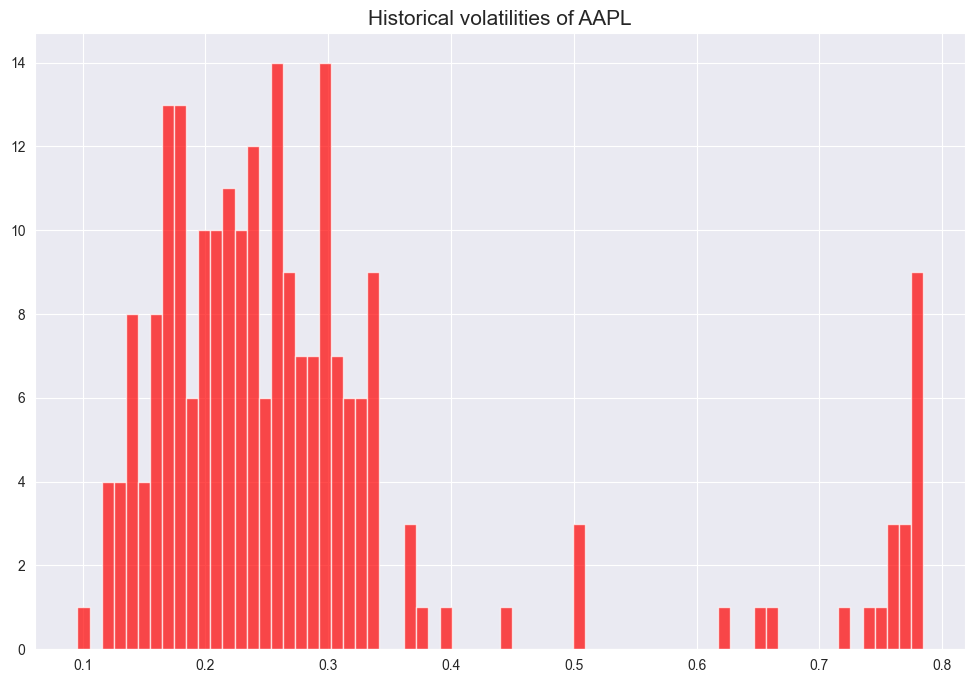

In [66]:
#Real World Distribution of Historical volatilites of a stock

tickers = ['AAPL']

for ticker in tickers:

    stock = yf.download(ticker, period = '1y', interval = '1d')

    #Historical volatilities of stock measured over 21 day trading days
    historical_vols = np.log(stock['Close']/stock['Close'].shift(1)).rolling(window = 21).std()*np.sqrt(252)

    plt.figure(figsize = (12, 8))
    plt.hist(historical_vols, bins = 70, color = 'red', alpha = .7)
    plt.title(f'Historical volatilities of {ticker}', size = 15)
    plt.show()